In [8]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.model_selection import cross_val_score
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df1=pd.read_csv('clean_apartment_data.csv')
df2=pd.read_csv('clean_home_data.csv')
df=pd.concat([df1,df2])
df.shape

(7406, 28)

In [10]:
X=df.drop(columns=['price','governorate_quality_confidence_low','governorate_quality_mid_price_housing_area',
                    'municipality_quality_confidence_low','municipality_quality_mid_price_housing_area','floor'
                    ],axis=1)
y=df['price']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
# Define MAPE and MdAPE functions
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def median_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    mask = y_true != 0
    return np.median(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [12]:
# Define the function to evaluate model performance
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name=None):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    
    # Calculate MAPE and MdAPE
    train_mape = mean_absolute_percentage_error(y_train, train_pred)
    test_mape = mean_absolute_percentage_error(y_test, test_pred)
    train_mdape = median_absolute_percentage_error(y_train, train_pred)
    test_mdape = median_absolute_percentage_error(y_test, test_pred)
    
    name = model_name if model_name else model.__class__.__name__
    print(f"\nModel: {name}")
    print(f"Training R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")
    print(f"Training MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    print(f"Training RMSE: {train_rmse:.2f}, Test RMSE: {test_rmse:.2f}")
    print(f"Training MAPE: {train_mape:.2f}%, Test MAPE: {test_mape:.2f}%")
    print(f"Training MdAPE: {train_mdape:.2f}%, Test MdAPE: {test_mdape:.2f}%")
    print(f"R² Difference (Overfitting): {train_r2 - test_r2:.4f}")

In [13]:
def cross_val_evaluate(model):
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    print(f"\nCross-validation R² scores: {cv_scores}")
    print(f"Mean CV R² score: {np.mean(cv_scores):.4f}")
    print(f"Standard deviation of CV R² scores: {np.std(cv_scores):.4f}")

    # Get feature importances
    feature_importances = model.feature_importances_
    features = X_train.columns
    importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
    importance_df = importance_df.sort_values('Importance', ascending=False).head(15)
    # Plot
    plt.figure(figsize=(12, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel('Importance')
    plt.title('Top 15 Feature Importances')
    plt.gca().invert_yaxis()  # Display the most important feature at the top
    plt.tight_layout()
    plt.show()

In [23]:
lr=LinearRegression()
# Add StandardScaler for feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test,"Linear Regression")



Model: Linear Regression
Training R²: 0.6830, Test R²: 0.6663
Training MAE: 177015.18, Test MAE: 180252.16
Training RMSE: 287760.04, Test RMSE: 307516.23
Training MAPE: 34.77%, Test MAPE: 35.87%
Training MdAPE: 22.85%, Test MdAPE: 24.11%
R² Difference (Overfitting): 0.0167


Starting hyperparameter search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Hyperparameter search completed!
Best parameters: {'oob_score': True, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_samples': 0.7, 'max_features': 0.7, 'max_depth': 15, 'bootstrap': True}
Best cross-validation MSE: 66179665639.83

Model: Random forest
Training R²: 0.8938, Test R²: 0.7383
Training MAE: 95475.65, Test MAE: 146075.83
Training RMSE: 168923.55, Test RMSE: 254935.09
Training MAPE: 18.17%, Test MAPE: 29.13%
Training MdAPE: 11.14%, Test MdAPE: 18.42%
R² Difference (Overfitting): 0.1555

Cross-validation R² scores: [0.76465403 0.72320371 0.75285733 0.75386627 0.73517519]
Mean CV R² score: 0.7460
Standard deviation of CV R² scores: 0.0148


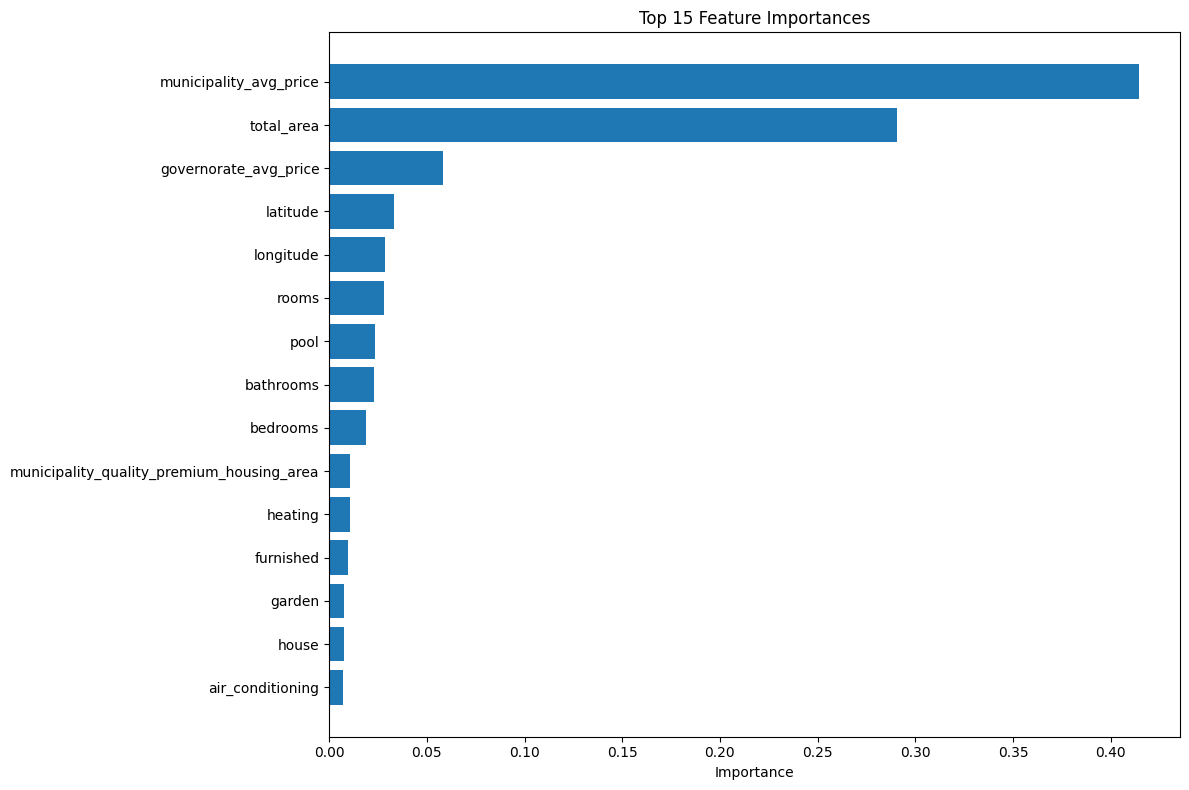

In [26]:
# Hyperparameter tuning for Random Forest with focus on reducing overfitting

# Define the parameter distribution with more regularization options
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5, 6, 7, 8, 10, 15, None],  # Include more restrictive depths
    'min_samples_split': [5, 10, 15, 20, 25],  # Increase minimum samples for splits
    'min_samples_leaf': [2, 4, 6, 8, 10],      # Increase minimum samples for leaves
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'bootstrap': [True],
    'oob_score': [True],
    'max_samples': [0.7, 0.8, 0.9, None]  # Add subsampling to reduce overfitting
}
# Create a base Random Forest model
rf = RandomForestRegressor(random_state=42)
# Create a cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)
# Set up RandomizedSearchCV with a scoring metric that penalizes complexity
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=100,  # Number of parameter settings sampled
    cv=cv,       # 5-fold cross-validation with shuffling
    verbose=2,
    random_state=42,
    n_jobs=-1,   # Use all available cores
    scoring='neg_mean_squared_error'  # Focus on error minimization
)
# Fit RandomizedSearchCV
print("Starting hyperparameter search...")
rf_random.fit(X_train, y_train)
print("Hyperparameter search completed!")

# Get the best parameters and score
print(f"Best parameters: {rf_random.best_params_}")
print(f"Best cross-validation MSE: {-rf_random.best_score_:.2f}")

# Create a model with the best parameters
best_rf = RandomForestRegressor(**rf_random.best_params_, random_state=42)
evaluate_model(best_rf, X_train, X_test, y_train, y_test,"Random forest")

cross_val_evaluate(best_rf)


Starting hyperparameter search for Gradient Boosting...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Hyperparameter search completed!
Best parameters: {'subsample': 1.0, 'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'max_depth': 8, 'learning_rate': 0.05, 'alpha': 0.9}
Best cross-validation MSE: 64332392868.86

Model: Gradient boost regressor
Training R²: 0.8842, Test R²: 0.7444
Training MAE: 108936.52, Test MAE: 145438.15
Training RMSE: 176421.02, Test RMSE: 251970.89
Training MAPE: 21.84%, Test MAPE: 29.18%
Training MdAPE: 14.20%, Test MdAPE: 18.62%
R² Difference (Overfitting): 0.1398

Cross-validation R² scores: [0.76446345 0.72750989 0.75748299 0.7760389  0.73320874]
Mean CV R² score: 0.7517
Standard deviation of CV R² scores: 0.0185


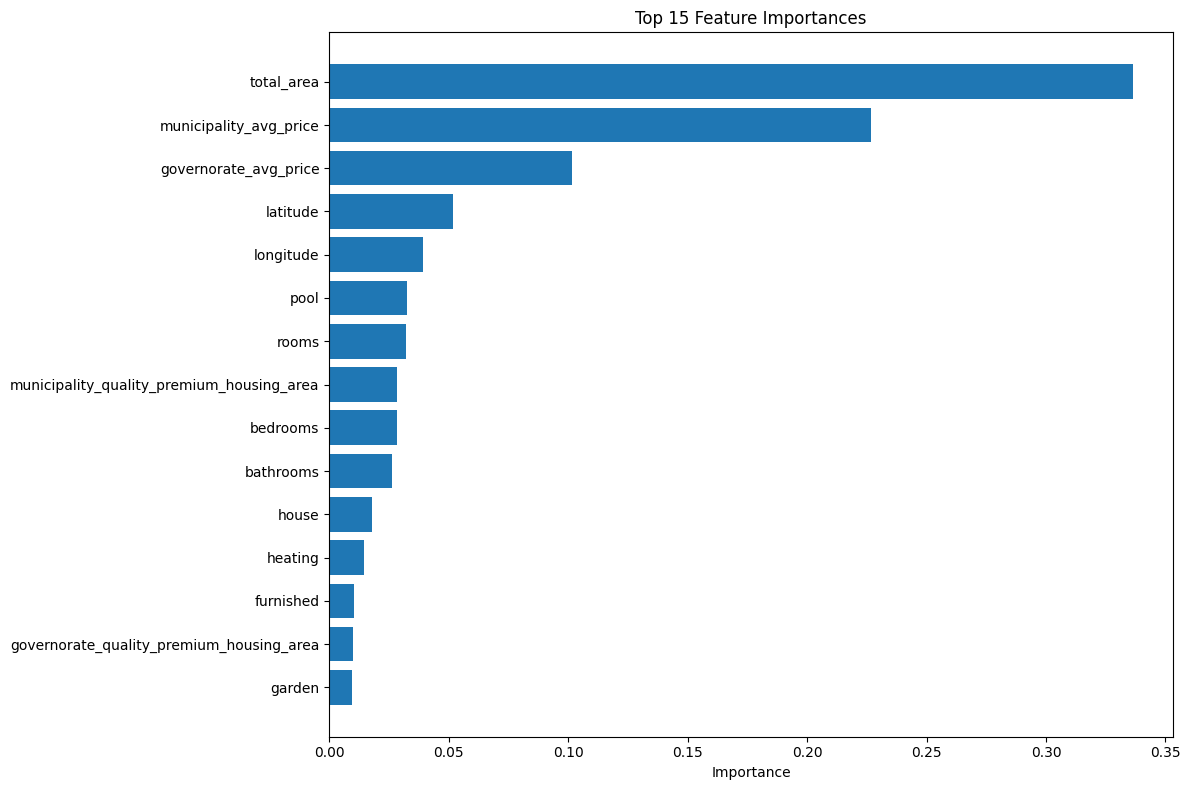

In [27]:
# Hyperparameter tuning for Gradient Boosting with focus on reducing overfitting

# Define the parameter distribution with regularization options
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'max_depth': [3, 4, 5, 6, 8],  # GBM typically uses shallower trees than RF
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],  # Similar to max_samples in RF
    'alpha': [0.1, 0.5, 0.9]  # Alpha for quantile loss (controls robustness)
}

# Create a base Gradient Boosting model
sgb = GradientBoostingRegressor(random_state=42)

# Create a cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Set up RandomizedSearchCV with a scoring metric that penalizes complexity
sgb_random = RandomizedSearchCV(
    estimator=sgb,
    param_distributions=param_dist,
    n_iter=100,  # Number of parameter settings sampled
    cv=cv,       # 5-fold cross-validation with shuffling
    verbose=2,
    random_state=42,
    n_jobs=-1,   # Use all available cores
    scoring='neg_mean_squared_error'  # Focus on error minimization
)

# Fit RandomizedSearchCV
print("Starting hyperparameter search for Gradient Boosting...")
sgb_random.fit(X_train, y_train)
print("Hyperparameter search completed!")

# Get the best parameters and score
print(f"Best parameters: {sgb_random.best_params_}")
print(f"Best cross-validation MSE: {-sgb_random.best_score_:.2f}")
# Create a model with the best parameters
best_sgb = GradientBoostingRegressor(**sgb_random.best_params_, random_state=42)
evaluate_model(best_sgb, X_train, X_test, y_train, y_test,"Gradient boost regressor")
cross_val_evaluate(best_sgb)

In [18]:
# ... existing code ...
from sklearn.ensemble import VotingRegressor, StackingRegressor
# Define the best Lasso model

# Simple averaging ensemble (VotingRegressor) with Lasso added
voting_ensemble = VotingRegressor(
    estimators=[
        ('rf', best_rf),
        ('sgb', best_sgb),
        ('lr', lr),
    ],
    weights=[1, 1,1]  # Equal weights for all models
)

evaluate_model(voting_ensemble, X_train, X_test, y_train, y_test,"Voting ensemble")


# Advanced stacking ensemble with a meta-learner and Lasso added
stacking_ensemble = StackingRegressor(
    estimators=[
        ('rf', best_rf),
        ('sgb', best_sgb),
        ('lr', lr),
    ],)
evaluate_model(voting_ensemble, X_train, X_test, y_train, y_test,"stacking ensemble")


Model: Voting ensemble
Training R²: 0.8410, Test R²: 0.7569
Training MAE: 125651.00, Test MAE: 145451.48
Training RMSE: 208912.83, Test RMSE: 233610.32
Training MAPE: 24.64%, Test MAPE: 29.86%
Training MdAPE: 16.04%, Test MdAPE: 19.28%
R² Difference (Overfitting): 0.0841

Model: stacking ensemble
Training R²: 0.8410, Test R²: 0.7569
Training MAE: 125651.00, Test MAE: 145451.48
Training RMSE: 208912.83, Test RMSE: 233610.32
Training MAPE: 24.64%, Test MAPE: 29.86%
Training MdAPE: 16.04%, Test MdAPE: 19.28%
R² Difference (Overfitting): 0.0841
